In [1]:
using LinearAlgebra
using Plots
using Statistics
using DelimitedFiles
using ScikitLearn

# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [2]:
#Função que retorna o módulo da diferença entre as normas dos nossos vetores, para conseguimos dimensionar o erro da nossa solução
get_erro(x_real, x_aprox) = abs(norm(x_real) - norm(x_aprox))

get_erro (generic function with 1 method)

In [3]:
@time get_erro([1,1,2], [1,1,1])

  0.000002 seconds (4 allocations: 160 bytes)


0.7174389352143007

### JacobiMethod(A, b, n)

Retorna uma aproximação da solução do sistema linear $Ax = b$, utilizando o método iterativo de Jacobi.

O método de Jacobi decompõe a matriz em $A = D + R$ e utiliza a iteração: $x^{(k+1)} = D^{-1}(b - Rx^{(k)})$

#### Argumentos
- `A::Matrix`: Matriz de coeficientes.
- `b::Vector`: Vetor resultante.
- `n::Int`: Número máximo de iterações.

#### Retorno
- `x::Vector`: Aproximação da solução x após as n iterações.


In [4]:
function JacobiMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0

    while erro >= ϵ
        xᵏ = copy(x)

        for i in 1:m
            diag_inv = 1/A[i,i]
            d = diag_inv * b[i] #Cálculo do D⁻¹[i,i]*b[i]

            soma = 0
            for j in 1:m #Cálculo do D⁻¹Rx
                if j != i
                    soma = soma + diag_inv * A[i,j] * xᵏ[j] #∑D⁻¹[i,i] * A[i,j] * xᵏ[j]
                end
            end

            x[i] = d - soma # x =  D⁻¹b - D⁻¹Rx 
        end

        erro = get_erro(x, xᵏ)
        it+=1
        push!(hist_erros, erro)
    end

    if verbose
        println("Solução Aproximada Gauss Jacobi: ", x)
        println("Histórico de erros: ", hist_erros)
    end

    if iteracoes
        return x, hist_erros, it
    end
    
        
    return x, hist_erros
end

JacobiMethod (generic function with 3 methods)

In [5]:
function GaussSeidelMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0

    while erro >= ϵ
        xᵏ = copy(x)

        for i in 1:m
            diag_inv = 1/A[i,i]
            d = diag_inv * b[i] #Cálculo do D⁻¹[i,i]*b[i]

            
            soma = 0
            for j in 1:m #Cálculo do D⁻¹Rx
                if j != i
                    soma = soma + diag_inv * A[i,j] * x[j]
                end
            end

            x[i] = d - soma
            
        end

        erro = get_erro(x, xᵏ)
        push!(hist_erros, erro)
    end

    if verbose
        println("Solução Aproximada Gauss Seidel: ", x)
        println("Histórico de erros: ", hist_erros)
    end

    if iteracoes
        return x, hist_erros, it
    end
    
    return x, hist_erros
end

GaussSeidelMethod (generic function with 3 methods)

Qual deveria ser a complexidade computacional do código que você escreveu?

Para melhor compreensão da complexidade das nossas funções, escolhi não utilizar algumas facilidades do Julia. Dessa forma, podemos perceber que em ambos possuímos 3 for's aninhados, o primeiro que vai até n e os dois últimos até m, o que configura uma complexidade $O(n*m^2)$.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [6]:
function plotar_comparativo(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o, yscale= :log10)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o, yscale= :log10)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo (generic function with 1 method)

Solução Real :[0.9770114942528736, 2.1494252873563218]
Solução Aproximada Jacobi :[0.9770114942532573, 2.149425287356318]
Solução Aproximada Gauss Seidel: [0.9770114942532573, 2.149425287356212]


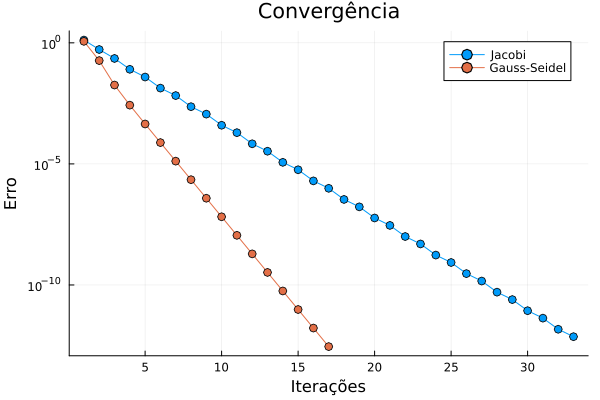

In [7]:
A = [15 9; 2 7]
b = [34, 17]

plotar_comparativo(A,b)


Solução Real :[0.3191489361702128, 0.40425531914893614]
Solução Aproximada Jacobi :[0.31914893617014073, 0.40425531914881263]
Solução Aproximada Gauss Seidel: [0.31914893617014073, 0.40425531914895774]


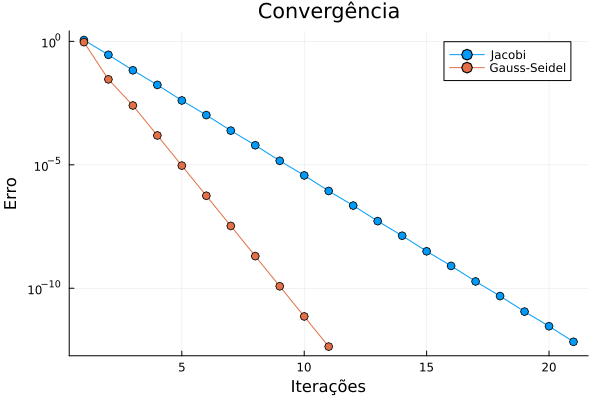

In [8]:
A = [10 2; 3 10]
b = [4, 5]

plotar_comparativo(A,b)

Solução Real :[3.7878281622911696, 1.73054892601432, -1.299045346062053]
Solução Aproximada Jacobi :[3.7878281622906815, 1.730548926013955, -1.2990453460624358]
Solução Aproximada Gauss Seidel: [3.787828162291648, 1.7305489260145164, -1.299045346062362]


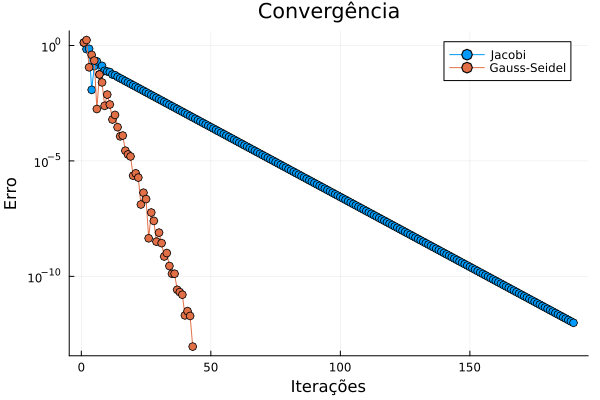

In [9]:
A = [15 9 8; 1 10 7; 21 4 35]
b = [62, 12, 41]

plotar_comparativo(A,b)


Solução Real :[2.8739649842320296, 0.19794628015721366, -0.698451165897687]
Solução Aproximada Jacobi :[2.873964984232412, 0.19794628015744797, -0.6984511658973622]
Solução Aproximada Gauss Seidel: [2.873964984232148, 0.19794628015720284, -0.6984511658977108]


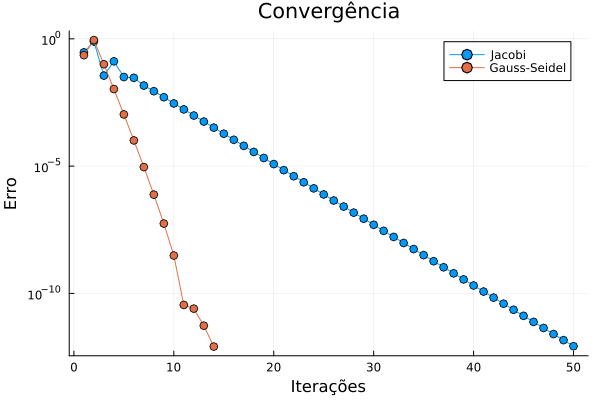

In [10]:
A = [42 16 17; 9 35 4; 13 22 54]
b = [112, 30, 4]

plotar_comparativo(A,b)

In [11]:
function plotar_comparativo_mod(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo_mod (generic function with 1 method)

In [12]:
# Código gerando gráficos

(Comentários)

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [13]:
A= rand(5,5)
b= rand(5)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [0.8968176426838538, -0.7589511301082608, 0.30839322394420304, 0.16855557534185012, -0.08963514349474738]
Solução Aproximada Gauss Jacobi: [Inf, Inf, Inf, Inf, Inf]
Histórico de erros: [7.0977300402414905, 31.76295381642378, 145.2987367526319, 653.8172392373292, 2946.495600659072, 13303.587890967076, 59953.226203453596, 270533.9432886056, 1.2197829580350318e6, 5.5023617852552235e6, 2.4813983303300615e7, 1.1192119988751926e8, 5.0476473261152494e8, 2.27660698315423e9, 1.0267727345171206e10, 4.6309265644862434e10, 2.0886097166594275e11, 9.419960271418312e11, 4.2485378536232866e12, 1.9161552202360016e13, 8.642142833984083e13, 3.897736220663962e14, 1.7579369969932228e15, 7.928558767263092e15, 3.575898195848608e16, 1.6127834916297165e17, 7.273894158333792e17, 3.280634850156487e18, 1.4796152738948157e19, 6.673285729670534e19, 3.009751457037665e20, 1.357442827906701e21, 6.12226974590141e21, 2.7612350293381497e22, 1.245358208751289e23, 5.6167513883221937e23, 2.533238704534465e24, 

([-1.2226330323006445, -1.859081996237474, 1.334304598565778, 0.4956431570503277, -0.48867100193321367], [0.4501650074480885])

In [14]:
A= rand(30,30)
b= rand(30)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [0.5041255187662098, 0.5887942658476296, -0.44932956367095406, -0.6175083971073984, -1.1306876400270933, 0.026297666635740367, 1.1691288304015568, 0.18533488042693147, 0.15930093508041196, 0.1384533405012163, 0.28653646984125647, 0.4385279329936636, 0.10004039812639268, 1.0296674808711113, 0.7527051265447318, -0.8505962774548821, 0.8000976438746819, -0.07092788526759046, -0.5793426056019568, 0.46390259009840706, -1.0435611824059396, 0.3237113605788306, 0.6046476019236319, -0.30384019815054003, 0.5624876663137729, 0.39648334965661913, 0.24154957463252938, -1.4971772554439025, -0.8047179065027146, 0.028970025237644685]
Solução Aproximada Gauss Jacobi: [-Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf]
Histórico de erros: [962.5948060247916, 60380.45147397858, 4.363794424255031e6, 3.215960129754489e8, 2.3157556452010788e10, 1.6831567805864624e12, 

([-1.9587571440601293e307, Inf, -Inf, NaN, NaN, NaN, NaN, NaN, NaN, NaN  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN], [1.4761917792844625e7, 6.758759695020677e12, 3.098821355551362e18, 1.4207700421918486e24, 6.514049445199665e29, 2.9866085933098248e35, 1.3693219501439183e41, 6.278166504128271e46, 2.8784592731764413e52, 1.3197368661514806e58  …  8.477517469180086e261, 3.8868336411006027e267, 1.7820636534828038e273, 8.170534574680773e278, 3.7460858990970983e284, 1.7175326088088122e290, 7.874667964855311e295, 3.6104348318443603e301, 1.6553383245073139e307, NaN])

In [15]:
A= rand(50, 50)
b= rand(50)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [-9.374955171768992, -1.9675735350511259, -0.9566741647675782, 1.8005656016043772, 3.5711360852691065, 1.9538637096110727, -6.728863122134998, 3.1128474248053073, -0.5013091110595468, -0.24131652712108784, -7.844970346957347, 0.29641973812584665, 4.330018057168772, 7.255814998357464, 5.210591227723918, 0.47293310206636774, 2.502151327951101, 4.539013233218554, -2.438132395107543, 8.71115857232262, 6.048845624990545, -2.378147286792118, -0.6817068097459305, -7.023311892831678, -1.3457675644532332, 6.430679509681369, -0.18328552874270798, -1.091550471000296, 3.486663511609837, -4.961276014935427, -5.969784172471252, -5.895972207621679, 4.915766393691711, -4.721229355751946, 5.549144334586949, -0.5338282471078324, -1.0184853059658145, 2.6325266902525737, -10.765593838089453, 0.32852559609239945, 6.656485661406384, -5.364449187036283, 5.620692878798421, 0.3548393798726224, 2.8706504113541778, -3.581407241639466, 2.2814674027559994, -3.264138266950574, 1.1721425065815911, -1.9

([-1.1004872195818665e306, 7.295988754411738e306, -8.813798270866557e306, 7.219245725557149e306, -2.2184578399185242e307, 1.5017759502246467e307, 6.878471131839224e307, 2.0097903813015532e307, -5.120817081322472e307, 5.8446615538985e307  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN], [6.663077666733404e9, 1.1367110864180746e18, 1.948548681759243e26, 3.340120983445269e34, 5.725496915964673e42, 9.814409441680582e50, 1.682345377230636e59, 2.883806697802276e67, 4.943301882505875e75, 8.47360314413891e83  …  2.3715750561020647e240, 4.0652556387596113e248, 6.968492675761671e256, 1.1945101240167313e265, 2.0475797317567287e273, 3.5098762861906526e281, 6.016484414892112e289, 1.0313208148406433e298, 1.767847383583115e306, NaN])

Em geral, os métodos não funcionam para matrizes `rand(m,m)`.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

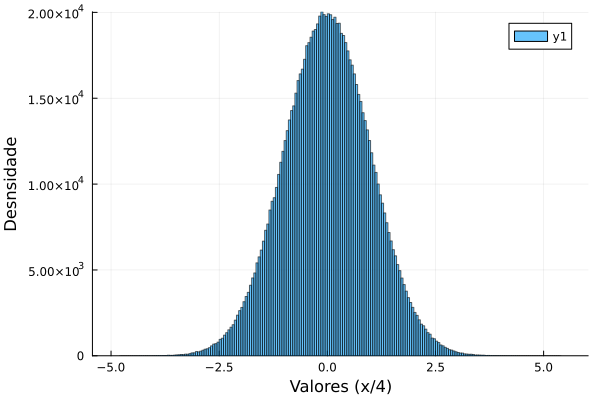

In [16]:
dist = randn(1000000)

histogram(dist, bins= :auto, xlabel= "Valores (x/4)", ylabel= "Desnsidade", alpha= 0.6)

In [17]:
row_sums = sum(abs.(A), dims= 2)
max_norm, row_idx = findmax(row_sums)
A[row_idx[1],:]

50-element Vector{Float64}:
 0.08185147520000269
 0.009112370925904667
 0.5580747630725738
 0.8202680742527683
 0.6623556530501407
 0.9125219716976349
 0.885647164585995
 0.9571990228824899
 0.6875368453135599
 0.35272292003014305
 ⋮
 0.5029154541695535
 0.8164289205473193
 0.5460020523902542
 0.32993799029480586
 0.01664669542103081
 0.7207720038286497
 0.456500260824928
 0.6303174068402578
 0.6499971528271205

In [18]:
M = rand(3, 3)

# Zerar a diagonal principal
M[diagind(M)] .= 0

3-element view(::Vector{Float64}, 1:4:9) with eltype Float64:
 0.0
 0.0
 0.0

In [19]:
A = randn(5,5)
D = Diagonal(diag(A))
A[diagind(A)] .= 0
M = inv(D)*(A)

5×5 Matrix{Float64}:
 -0.0         0.0169447  -0.274715   0.738377  -0.802022
 -0.0460991  -0.0         0.844321   0.128449   0.659711
 -0.0308878  -0.195086   -0.0        3.11015   -0.106636
 -1.27874    -0.56834    -1.61134   -0.0        0.919424
 -4.4195     -1.16134     0.848549  -0.486019   0.0

In [20]:
# data = Float64[]
# f(m) = 4*m

# for i in 1:100000
#     A = randn(2, 2) + 3.648929468919049*Matrix(I,2,2)
#     D = Diagonal(diag(A))
#     A[diagind(A)] .= 0
#     M = inv(D)*(A) 

#     row_sums = sum(abs.(M), dims= 2)
#     max_norm, row_idx = findmax(row_sums)
#     k = max_norm
#     push!(data, k)
# end

# histogram(data, bins= :auto, alpha= 0.6)






In [21]:
# resultado = count(x -> x < 1, data)
# resultado/length(data)

In [22]:
data_k_min = Float64[]

for dim in 2:50
    data = Float64[]
    println(dim)
    for i in 1:100000
    A = randn(dim,dim)
    diagonal = diag(A)
    A[diagind(A)] .= 0

    row_sums = sum(abs.(A), dims= 2)
    max_norm, row_idx = findmax(row_sums)
    k_min = max_norm - diagonal[row_idx[1]]
    push!(data, k_min)
    end
    k95 = quantile(data, 0.95)
    push!(data_k_min, k95)
end

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [ ]:
data_k_min

In [ ]:
plot(2:50, data_k_min)

In [ ]:
function createPhi(vetor, n)
    Phi = zeros(size(vetor, 1), n+1)
    for i in 1:n+1
        Phi[:,i] .+= vetor.^(i-1)
    end 
    return Phi

end

In [ ]:
Phi1 = createPhi([2:50;], 1)

In [ ]:
function linear_regression_PI(Phi, target)
    PhiTPhi = transpose(Phi)*Phi
    pinv = inv(PhiTPhi)*transpose(Phi)
    w_learned = pinv*target
    return w_learned


end

In [ ]:
w_learned = linear_regression_PI(Phi1, data_k_min)

In [ ]:
f(m) =   1.7992749418770098 + m * 1.0795403015420795 

function test(dim)
data = Float64[]

for i in 1:1000
    A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim)
    D = Diagonal(1 ./ diag(A))
    A[diagind(A)] .= 0
    M = D*A

    row_sums = sum(abs.(M), dims= 2)
    max_norm, row_idx = findmax(row_sums)
    k = max_norm
    push!(data, k)
end
    resultado = count(x -> x < 1, data)
    # resultado/length(data)
    println(resultado/length(data))

end

In [ ]:
dim =2000

A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim) 
b = rand(dim)

plotar_comparativo(A,b)

In [ ]:
test(50)

In [ ]:
dim = 4
A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim)
b = randn(dim)

plotar_comparativo(A,b)

In [ ]:
# Código (gerando possivelmente gráficos ou tabelas)

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

In [23]:
# Código
it_j = 1
it_gs = 0

for it_j > it_gs
    A = randn(4,4) + f(4)*Matrix(I,4, 4)
    b = rand(4)

    x_j, hist_j, it_j = JacobiMethod(A,b,10^(-12),false,true)
    x_gs, hist_gs, it_gs =GaussSeidelMethod(A,b,10^(-12),false,true)

    if it_j < it_gs
        println(A)
    end
end

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\C3007807\github_repos\fgv_aln\Trab_2\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X62sZmlsZQ==.jl:5:9

for it_j > it_gs
#       └──────┘ ── invalid iteration spec: expected one of `=` `in` or `∈`

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [24]:
# test(1000)

In [ ]:
# Código

(Comentários)